INCEPTIONV3 Program 4
05/03/2026 Thursday



In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
from keras.applications import InceptionV3
from tensorflow.keras.datasets import cifar10
from keras.utils import to_categorical
#from keras.models import Sequential
#from keras.optimizers import Adam
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train,x_test = x_train / 255.0,x_test /255.0
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [3]:
base_model = InceptionV3(weights='imagenet',include_top=False,input_shape=(96,96,3))

In [4]:
base_model.trainable = False

In [5]:
#To Correctly input the data into the model
print(x_train.shape)  
print(y_train.shape)  
print(x_test.shape)  
print(y_test.shape)  

(50000, 32, 32, 3)
(50000, 10)
(10000, 32, 32, 3)
(10000, 10)


In [6]:
#Freeze the layer of VGG16
for layer in base_model.layers:
    layer.trainable = False

In [7]:
model= models.Sequential()
model.add(layers.UpSampling2D(size=(3,3),interpolation='bilinear'))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

In [8]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

In [9]:
#data augmentation
#datagen = ImageDataGenerator(
   # rotation_range=15,
   # width_shift_range=0.1,
    #height_shift_range=0.1,
    #horizontal_flip=True)
#increase no of images by 5 times

In [10]:
#train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 310s 383ms/step - accuracy: 0.5711 - loss: 1.2644 - val_accuracy: 0.6507 - val_loss: 1.0089
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 389ms/step - accuracy: 0.6407 - loss: 1.0380 - val_accuracy: 0.6679 - val_loss: 0.9559
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 322s 412ms/step - accuracy: 0.6594 - loss: 0.9781 - val_accuracy: 0.6760 - val_loss: 0.9390
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 338s 432ms/step - accuracy: 0.6783 - loss: 0.9263 - val_accuracy: 0.6796 - val_loss: 0.9347
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 322s 412ms/step - accuracy: 0.6932 - loss: 0.8830 - val_accuracy: 0.6817 - val_loss: 0.9430


In [11]:
#Evaluate The Model
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

313/313 - 57s - 181ms/step - accuracy: 0.6817 - loss: 0.9430
Test Accuracy:0.6816999912261963


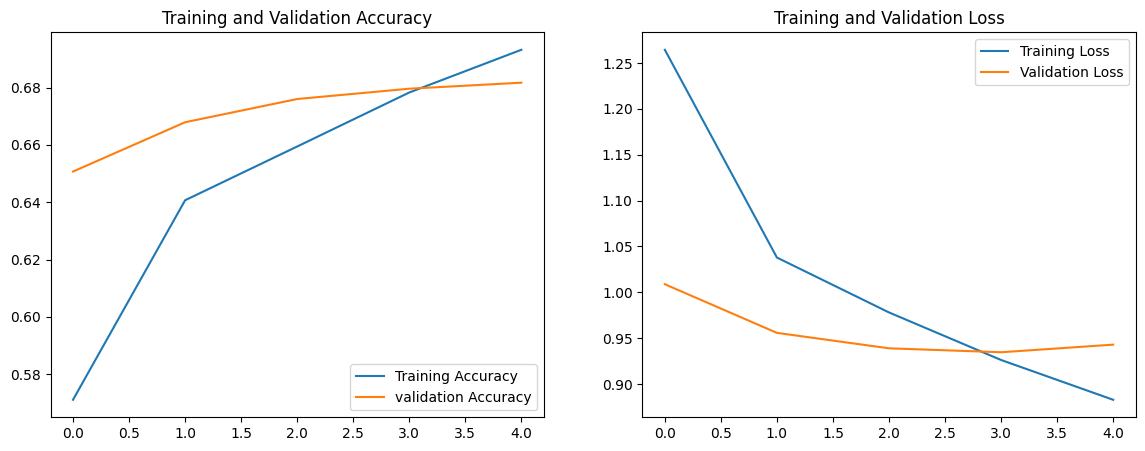

In [12]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./Inception.png')
plt.show()
